XGBOOST - ROC CURVE & AUC

AUC Score: 0.9779


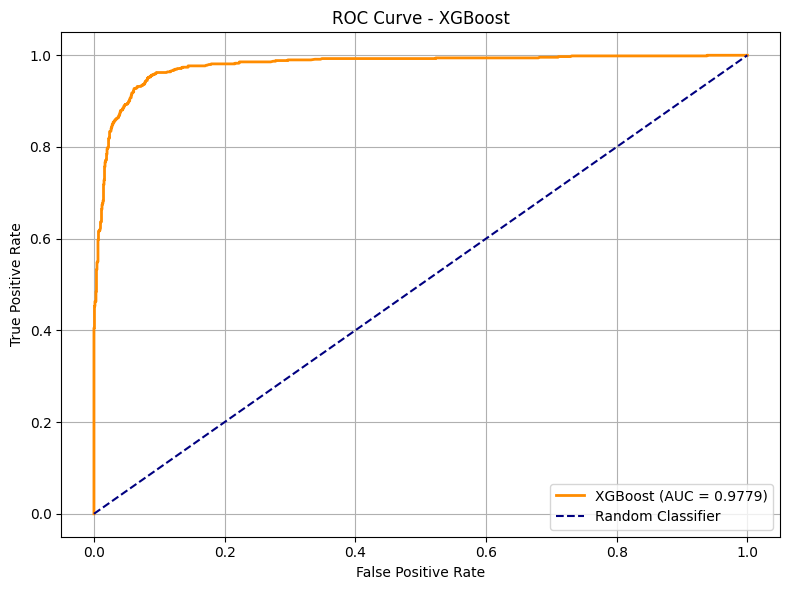

In [ ]:
# ============================================
# XGBOOST - ROC CURVE & AUC
# ============================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import roc_curve, roc_auc_score


# ============================================
# 1. LOAD DATASET
# ============================================

df = pd.read_csv("phishing_website_cleaned.csv")


# ============================================
# 2. SELECT FEATURES
# ============================================

URL_FEATURES = [
    # URL features
    "qty_dot_url",
    "qty_hyphen_url",
    "qty_underline_url",
    "qty_slash_url",
    "qty_questionmark_url",
    "qty_equal_url",
    "qty_at_url",
    "qty_and_url",
    "qty_exclamation_url",
    "qty_space_url",
    "qty_tilde_url",
    "qty_comma_url",
    "qty_plus_url",
    "qty_asterisk_url",
    "qty_hashtag_url",
    "qty_dollar_url",
    "qty_percent_url",
    "length_url",

    # Domain features
    "qty_dot_domain",
    "qty_hyphen_domain",
    "qty_underline_domain",
    "qty_slash_domain",
    "qty_questionmark_domain",
    "qty_equal_domain",
    "qty_at_domain",
    "qty_and_domain",
    "qty_exclamation_domain",
    "qty_space_domain",
    "qty_tilde_domain",
    "qty_comma_domain",
    "qty_plus_domain",
    "qty_asterisk_domain",
    "qty_hashtag_domain",
    "qty_dollar_domain",
    "qty_percent_domain",

    # Domain / security features
    "qty_vowels_domain",
    "domain_length",
    "domain_in_ip",
    "server_client_domain",
    "email_in_url",
    "tls_ssl_certificate",
    "url_shortened"
]


# Keep only features available in dataset
available_features = [
    feature for feature in URL_FEATURES
    if feature in df.columns
]


X = df[available_features].copy()
y = df["phishing"].copy()


# ============================================
# 3. REMOVE CONSTANT FEATURES (27 FEATURES)
# ============================================

constant_features = [
    column for column in X.columns
    if X[column].nunique() <= 1
]

X = X.drop(columns=constant_features)


# ============================================
# 4. TRAIN / TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# ============================================
# 5. TRAIN XGBOOST MODEL
# ============================================

model = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

model.fit(X_train, y_train)


# ============================================
# 6. GET PREDICTED PROBABILITIES
# ============================================

y_prob = model.predict_proba(X_test)[:, 1]


# ============================================
# 7. CALCULATE ROC CURVE
# ============================================

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)


# ============================================
# 8. CALCULATE AUC
# ============================================

auc_score = roc_auc_score(
    y_test,
    y_prob
)


print("=" * 60)
print("XGBOOST - ROC CURVE & AUC")
print("=" * 60)

print(f"\nAUC Score: {auc_score:.4f}")


# ============================================
# 9. PLOT ROC CURVE
# ============================================

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    color="darkorange",
    lw=2,
    label=f"XGBoost (AUC = {auc_score:.4f})"
)

# Random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    color="navy",
    lw=1.5,
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - XGBoost")

plt.legend(
    loc="lower right"
)

plt.grid(True)

plt.tight_layout()

plt.show()

In [ ]:
import joblib

joblib.dump(model, 'random_forest_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

joblib.dump(X.columns.tolist(), 'feature_names.pkl')

['feature_names.pkl']

In [ ]:
import joblib


joblib.dump(model, 'rf_model.pkl')
joblib.dump(logistic_model, 'lr_model.pkl')
joblib.dump(xgb_model, 'xgb_model.pkl')
joblib.dump(hist_model, 'hist_model.pkl')

# Scaler & Feature Names
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(X.columns.tolist(), 'feature_names.pkl')

['feature_names.pkl']